# Ridge Regression

> 📘 **Instructor Curriculum** — M07 Machine Learning, scikit-learn module.

Linear regression has one goal. Make the error on the training rows as small as it can.
Nothing stops it. If a bigger slope fits the training rows a little better, it takes the
bigger slope.

Ridge has two goals:

```text
LinearRegression : make the error small
Ridge            : make the error small  AND  keep the slope small
```

Those two goals pull against each other. **`alpha`** is the dial that decides which one
wins.

| | `LinearRegression` | `Ridge` |
|---|---|---|
| what it minimises | error only | error **+ a penalty on the size of the slope** |
| the knob you set | none | `alpha` |
| `alpha = 0` | — | same model as `LinearRegression` |
| big `alpha` | — | the slope shrinks and the line goes flat |

Everything else is the same class you already know: `fit`, `predict`, `score`, `coef_`,
`intercept_`.


In [1]:
from sklearn.datasets import make_regression
x,y = make_regression(n_features=1, noise=5, n_samples=10000)
import matplotlib.pyplot as plt



## 1. The data

`make_regression` builds a straight line and adds noise to it. One input column, one
output number, 10,000 rows.

The cell above has no `random_state`, so it draws new data on every run. The next cell
draws the same thing with a seed, so the numbers written in this notebook stay true.


In [2]:
# The cell above has no random_state, so it draws new data every run.
# Draw it once with a seed so the numbers in this notebook stay true.
x, y = make_regression(n_features=1, noise=5, n_samples=10000, random_state=42)
print("x:", x.shape, " y:", y.shape)


x: (10000, 1)  y: (10000,)


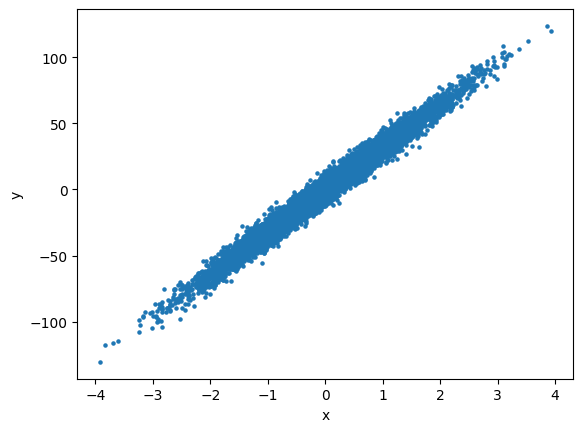

In [3]:
plt.scatter(x,y,s=5)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## 2. Split the data

8,000 rows to train on. 2,000 kept hidden for scoring.

We are about to compare several models, so they all have to be judged on the same hidden
rows.


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=0)

## 3. `Ridge()` — the default `alpha = 1.0`

Same three steps as always. `Ridge()` with no argument means `alpha = 1.0`.

### What `alpha` actually does

Ridge adds one extra cost:

```text
   total cost  =  how wrong you are   +   alpha x (slope x slope)
                          |                          |
                  the only cost that            this part is new
                  LinearRegression had
```

A big slope now costs something. `alpha` is the price tag on it.

- `alpha` small → a big slope is cheap → keep the slope the data wants
- `alpha` big → a big slope is expensive → shrink it

Two things to remember:

1. **Only the slope is charged. The intercept is not.** This matters in section 9.
2. **`alpha` is a hyperparameter.** You choose it, the data does not. That is why it has
   no underscore, while `coef_` and `intercept_` do.


In [5]:
from sklearn.linear_model import Ridge
reg = Ridge()
reg.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

## 4. `predict()` and `score()`

Nothing changed here. Ridge still ends up with one slope and one intercept, so `predict`
is still `m * x + c`.

`score` gives R² on the 2,000 hidden rows: **`0.9769`**. Almost perfect. On 8,000 rows an
`alpha` of 1 is far too small to matter.


In [6]:
reg.predict(X_test)

array([26.7963039 ,  0.51790922, -2.20125853, ..., 17.8376875 ,
       20.43818735, 43.21880194], shape=(2000,))

In [7]:
reg.score(X_test,y_test)

0.9769119096071136

## 5. The model is two numbers

| | value | meaning |
|---|---|---|
| `coef_` | `31.985047` | `y` moves 31.99 when `x` moves 1 |
| `intercept_` | `0.066653` | the height of the line at `x = 0` |

Remember **`31.98`**. That is the number the rest of this notebook shrinks.

Plain `LinearRegression` on the same rows gives **`31.989006`**. So `alpha = 1` only cost
us `0.004`.


In [8]:
reg.coef_

array([31.98504656])

In [9]:
reg.intercept_

np.float64(0.0666527917276602)

## 6. Draw the line

`reg.predict(x)` runs the formula on all 10,000 rows, so the orange dots draw the model
right across the picture.

The orange dots form a straight line. The blue cloud is the real noisy data. The line
runs up the middle of it.


In [10]:
y_pred= reg.predict(x)

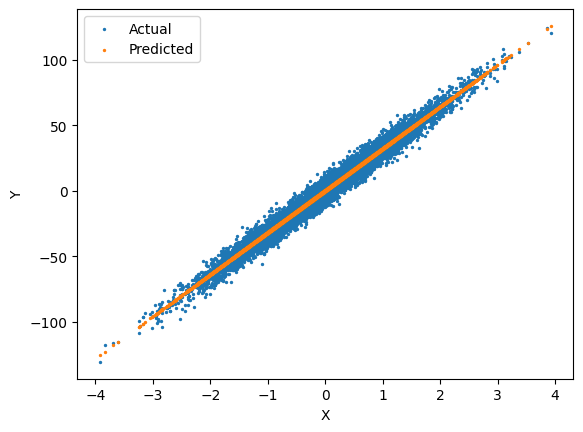

In [11]:
plt.scatter(x,y,label='Actual',s=2)
plt.scatter(x,y_pred,label='Predicted',s=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

## 7. `alpha = 100`

Same code, one argument changed. The score barely moves (`0.976912` → `0.976598`) and
`coef_` drops from `31.985` to `31.598`.

### The one formula worth knowing

With one input column, this is exactly what Ridge does to the slope:

```text
   new slope  =  old slope  x   S / (S + alpha)

   S = how spread out your x values are on the training rows
     = sum of (x - average x) squared
```

`S / (S + alpha)` is the **shrink factor**. It is always between 0 and 1, so the slope
can only get smaller. It never grows, and it never flips sign.

Here `S = 8078.97`, so:

| `alpha` | `S / (S + alpha)` | slope |
|---:|---:|---:|
| `1` | `0.9999` | `31.985` |
| `100` | `0.9878` | `31.598` |
| `8,079` (the same size as `S`) | `0.5000` | `15.994` — exactly half |
| `100,000` | `0.0748` | `2.391` |
| `10,000,000` | `0.0008` | `0.026` |

Those are the real numbers this notebook printed.

### Why a bigger `alpha` flattens the line

```text
   small alpha  ->  shrink factor near 1   ->  slope stays 31.99  ->  steep line
   bigger alpha ->  shrink factor smaller  ->  slope shrinks      ->  line tilts down
   huge alpha   ->  shrink factor near 0   ->  slope near 0       ->  flat line
```

`alpha` **rotates** the line. It does not slide it up or down.

One useful side effect: `S` grows with the number of rows. So the same `alpha` is weaker
on a big dataset. `alpha = 100` is nothing on 8,000 rows and a lot on 50 rows. That is
why you cannot copy an `alpha` from another project.


In [12]:
from sklearn.linear_model import Ridge
reg = Ridge(alpha=100)
reg.fit(X_train,y_train)
reg.score(X_test, y_test)

0.9765976836816457

### What `alpha = 100` looks like

Almost nothing. The line is 1.2% less steep and the score changes in the fourth decimal.


In [13]:
y_pred = reg.predict(x)

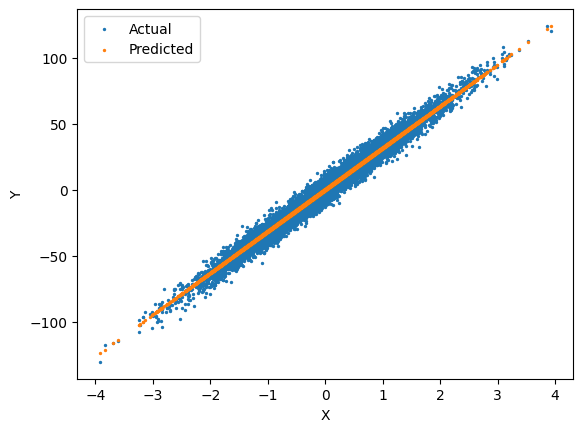

In [14]:
plt.scatter(x,y,label='Actual',s=2)
plt.scatter(x,y_pred,label='Predicted',s=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [15]:
reg.coef_

array([31.59789266])

## 8. `alpha = 100,000`

Now `alpha` is much bigger than `S`, so the penalty wins:

```text
   8078.97 / (8078.97 + 100000)  =  0.0748
   31.989 x 0.0748               =  2.39
```

The slope falls from `31.99` to `2.39`. R² falls from `0.977` to `0.140`.

In the chart the orange dots are now an almost flat band lying across the middle of the
blue cloud.


In [16]:
reg = Ridge(alpha=100000)
reg.fit(X_train,y_train)
reg.score(X_test, y_test)

0.13955010448963978

In [17]:
y_pred = reg.predict(x)

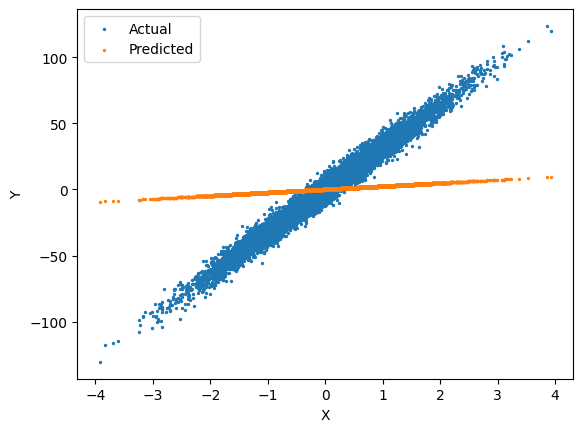

In [18]:
plt.scatter(x,y,label='Actual',s=2)
plt.scatter(x,y_pred,label='Predicted',s=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [19]:
reg.coef_

array([2.39119767])

## 9. `alpha = 10,000,000` — the line becomes the average

Shrink factor `0.0008`. The slope is `0.026`, which is zero for any real purpose. R² is
`0.0015`.

Two things meet here:

1. **The slope is gone**, so `predict` returns nearly the same number for every `x`.
2. **The intercept was never charged**, so it is still free. With no slope, the best
   single number to predict is the **average of `y_train`**.

```text
   alpha gets huge  ->  slope      -> 0
                        intercept  -> average of y_train = 0.055079
                        prediction -> 0.055079, for every row
```

The notebook prints `intercept_ = 0.055089`. The average of `y_train` is `0.055079`.

And that is why R² is 0. R² compares your model against *"always guess the average"*.
R² = 0 means "no better than guessing the average" — and we have just built a model that
**is** the average.


In [20]:
reg = Ridge(alpha=10000000)
reg.fit(X_train,y_train)
reg.score(X_test, y_test)

0.0014861178826479637

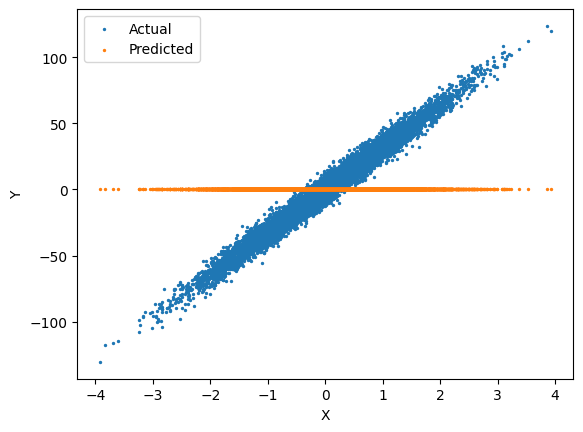

In [21]:
y_pred = reg.predict(x)
plt.scatter(x,y,label='Actual',s=2)
plt.scatter(x,y_pred,label='Predicted',s=2)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

In [22]:
reg.coef_

array([0.02582296])

## 10. The alpha table

Every value of `alpha` side by side, all fitted on the same split. The `formula` column
is the shrink factor from section 7 applied to the unpenalised slope, so it shows that
the formula and sklearn agree.


In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge

# S is the only property of the data that alpha competes with
S     = ((X_train - X_train.mean()) ** 2).sum()
ols   = LinearRegression().fit(X_train, y_train)
w_ols = ols.coef_[0]

rows = []
for a in [0, 1, 100, 1_000, round(S), 10_000, 100_000, 1_000_000, 10_000_000]:
    m = LinearRegression() if a == 0 else Ridge(alpha=a)
    m.fit(X_train, y_train)
    rows.append({
        "alpha":       a,
        "S/(S+alpha)": S / (S + a),
        "coef_":       m.coef_[0],
        "formula":     w_ols * S / (S + a),
        "intercept_":  m.intercept_,
        "train R2":    m.score(X_train, y_train),
        "test R2":     m.score(X_test, y_test),
    })

table = pd.DataFrame(rows)
print(f"S             = sum of squared centred x on the 8000 train rows = {S:,.4f}")
print(f"w_ols         = the unpenalised slope                          = {w_ols:.6f}")
print(f"mean(y_train) = where the flat line ends up                    = {y_train.mean():.6f}")
print(f"does the formula reproduce coef_ everywhere? -> "
      f"{np.allclose(table['coef_'], table['formula'])}")
table.round(6)


S             = sum of squared centred x on the 8000 train rows = 8,078.9688
w_ols         = the unpenalised slope                          = 31.989006
mean(y_train) = where the flat line ends up                    = 0.055079
does the formula reproduce coef_ everywhere? -> True


,alpha,S/(S+alpha),coef_,formula,intercept_,train R2,test R2
0,0,1.000000,31.989006,31.989006,0.066654,0.976090,0.976914
1,1,0.999876,31.985047,31.985047,0.066653,0.976090,0.976912
2,100,0.987774,31.597893,31.597893,0.066513,0.975944,0.976598
3,1000,0.889855,28.465587,28.465587,0.065379,0.964248,0.963682
4,8079,0.499999,15.994472,15.994472,0.060867,0.732066,0.729147
5,10000,0.446871,14.294962,14.294962,0.060252,0.677453,0.674523
6,100000,0.074751,2.391198,2.391198,0.055945,0.140473,0.139550
7,1000000,0.008014,0.256367,0.256367,0.055172,0.015583,0.015406
8,10000000,0.000807,0.025823,0.025823,0.055089,0.001575,0.001486


### Reading the table

| `alpha` | shrink factor | `coef_` | `intercept_` | test R² | what happened |
|---:|---:|---:|---:|---:|---|
| `0` | `1.0000` | `31.989006` | `0.066654` | `0.976914` | plain `LinearRegression` |
| `1` | `0.9999` | `31.985047` | `0.066653` | `0.976912` | the default. No visible effect |
| `100` | `0.9878` | `31.597893` | `0.066513` | `0.976598` | 1.2% flatter, no real cost |
| `1,000` | `0.8899` | `28.465587` | `0.065379` | `0.963682` | a visible tilt |
| **`8,079`** | **`0.5000`** | **`15.994472`** | `0.060867` | `0.729147` | **the slope is exactly halved** |
| `10,000` | `0.4469` | `14.294962` | `0.060252` | `0.674523` | falling fast |
| `100,000` | `0.0748` | `2.391198` | `0.055945` | `0.139550` | nearly flat |
| `1,000,000` | `0.0080` | `0.256367` | `0.055172` | `0.015406` | flat |
| `10,000,000` | `0.0008` | `0.025823` | `0.055089` | `0.001486` | the line **is** the average, `0.055079` |

Three things this table says:

1. **The slope never reaches 0.** The shrink factor is always above 0, so Ridge gets
   close to zero but never arrives. (`Lasso` is the one that sets coefficients to exactly
   0.)
2. **The action happens around `S`.** Below `alpha = 100` nothing happens. Above
   `alpha = 1,000,000` everything has already happened. So `alpha` is searched in jumps
   of ten — `0.1, 1, 10, 100, 1000` — never `1, 2, 3, 4`.
3. **The intercept barely moves.** It is not being charged. It just re-settles on the
   average of `y` as the slope disappears.


## 11. Wrap up

### Ridge in three lines

```text
cost       =  error  +  alpha x slope x slope
new slope  =  old slope x S/(S + alpha)          S = spread of x on the train rows
huge alpha =>  slope -> 0,  line goes flat at the average of y,  R2 -> 0
```

### Common mistakes

| Mistake | What actually happens |
|---|---|
| Copying an `alpha` from another project | `alpha` only means something next to `S`, and `S` grows with your row count. The same number is heavy on 50 rows and invisible on 8,000. |
| Trying `alpha` as `1, 2, 3, 4, 5` | Nothing changes at that scale. Move in jumps of ten: `0.01, 0.1, 1, 10, 100, 1000`. |
| Expecting Ridge to improve every model | It only helps when the model is overfitting. This dataset has 10,000 rows and one clean column, so there is nothing to fix and every increase of `alpha` only makes the score worse. |
| Expecting Ridge to remove useless columns | It shrinks them but never to exactly 0. `Lasso` is the tool that does that. |
| `make_regression` with no `random_state` | Every run is a different dataset, so nothing you write down stays true. Section 1 is the fix. |

### Key takeaway

**If you remember only one thing:** `alpha` shrinks the slope by `S / (S + alpha)`. A
small `alpha` gives you `LinearRegression`. A large `alpha` drives the slope to zero, so
the line goes flat at the average of `y` — and a model that always predicts the average
is exactly what R² = 0 means.
